# MS2 AB: GSE96583 Data Wrangling and EDA

This notebook is self-contained: data download, metadata attachment, QC, shared-gene alignment, Harmony batch correction, and the milestone 2 figures all live here.


## Data Description

`GSE96583` is the GEO series **"Multiplexing droplet-based single cell RNA-sequencing using genetic barcodes"**. It contains five PBMC count matrices:

- `batch1`: samples `A`, `B`, `C`
- `batch2`: `ctrl` and IFN-beta `stim`

That makes it useful for milestone 2 because one dataset already contains both:

- a strong technical batch split (`batch1` vs `batch2`)
- a biological condition split inside `batch2` (`ctrl` vs `stim`)

Source links:
- GEO accession: <https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE96583>
- GEO supplementary FTP: <https://ftp.ncbi.nlm.nih.gov/geo/series/GSE96nnn/GSE96583/suppl/>

Note on the original paper code: the public `demuxlet_paper_code` repository mostly exposes demuxlet outputs such as `*.sm.best`, barcode files, and downstream comparison scripts, rather than a full raw scRNA-seq preprocessing notebook. So below we use a standard single-cell preprocessing workflow directly in this notebook.


In [1]:
from pathlib import Path
import gzip
import tarfile
from urllib.request import urlretrieve

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from matplotlib.lines import Line2D
from scipy import io
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_colwidth', 120)
sc.settings.set_figure_params(dpi=110, facecolor='white')

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'data').exists():
    ROOT = ROOT.parent
if not (ROOT / 'data').exists():
    raise FileNotFoundError('Could not locate the project root containing the data directory.')

RAW_ROOT = ROOT / 'data' / 'raw' / 'GSE96583'
PROCESSED_ROOT = ROOT / 'data' / 'processed'
RAW_ROOT.mkdir(parents=True, exist_ok=True)
PROCESSED_ROOT.mkdir(parents=True, exist_ok=True)

RAW_ARCHIVE_URL = 'https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSE96583&format=file'
SUPPL_URL_ROOT = 'https://ftp.ncbi.nlm.nih.gov/geo/series/GSE96nnn/GSE96583/suppl'
EXPECTED_RAW_ARCHIVE_MEMBERS = [
    'GSM2560245_A.mat.gz', 'GSM2560245_barcodes.tsv.gz',
    'GSM2560246_B.mat.gz', 'GSM2560246_barcodes.tsv.gz',
    'GSM2560247_C.mat.gz', 'GSM2560247_barcodes.tsv.gz',
    'GSM2560248_2.1.mtx.gz', 'GSM2560248_barcodes.tsv.gz',
    'GSM2560249_2.2.mtx.gz', 'GSM2560249_barcodes.tsv.gz',
]
SUPPLEMENTARY_FILES = [
    'GSE96583_batch1.genes.tsv.gz',
    'GSE96583_batch1.total.tsne.df.tsv.gz',
    'GSE96583_batch2.genes.tsv.gz',
    'GSE96583_batch2.total.tsne.df.tsv.gz',
    'GSE96583_genes.txt.gz',
    'filelist.txt',
]
BATCH1_SAMPLE_MAP = {'GSM2560245_A': 'A', 'GSM2560246_B': 'B', 'GSM2560247_C': 'C'}
BATCH2_SAMPLE_MAP = {'GSM2560248_2.1': 'ctrl', 'GSM2560249_2.2': 'stim'}
MIN_GENES = 200
MIN_CELLS = 3
SCRUBLET_EXPECTED_DOUBLET_RATE = 0.08
TAIL_QUANTILE = 0.995
HVG_PER_BATCH = 2000
UMAP_MIN_DIST = 0.2
BATCH_PALETTE = {'batch1': '#133C55', 'batch2': '#D05D4E'}
CELL_PALETTE = {
    'CD4 T cells': '#1b9e77',
    'CD14+ Monocytes': '#d95f02',
    'B cells': '#7570b3',
    'CD8 T cells': '#e7298a',
    'NK cells': '#66a61e',
    'FCGR3A+ Monocytes': '#e6ab02',
    'Dendritic cells': '#a6761d',
    'Megakaryocytes': '#666666',
}


def download_file(url, destination):
    destination = Path(destination)
    if not destination.exists():
        destination.parent.mkdir(parents=True, exist_ok=True)
        print(f'Downloading {destination.name}')
        urlretrieve(url, destination)
    return destination


def ensure_raw_data():
    archive_path = RAW_ROOT.parent / 'GSE96583.tar'
    download_file(RAW_ARCHIVE_URL, archive_path)
    missing = [name for name in EXPECTED_RAW_ARCHIVE_MEMBERS if not (RAW_ROOT / name).exists()]
    if missing:
        print('Extracting GSE96583 tar archive')
        with tarfile.open(archive_path, 'r') as tar:
            tar.extractall(RAW_ROOT)
    for name in SUPPLEMENTARY_FILES:
        download_file(f'{SUPPL_URL_ROOT}/{name}', RAW_ROOT / name)
    return RAW_ROOT


def raw_file_inventory(raw_dir=RAW_ROOT):
    rows = []
    for path in sorted(Path(raw_dir).glob('*')):
        if path.is_file():
            rows.append({
                'file': path.name,
                'size_mb': round(path.stat().st_size / (1024 * 1024), 2),
                'kind': (
                    'count matrix' if path.name.endswith(('.mat.gz', '.mtx.gz')) else
                    'barcode table' if 'barcodes' in path.name else
                    'gene metadata' if 'genes' in path.name else
                    'cell metadata' if 'tsne' in path.name else
                    'inventory' if path.name.endswith('.txt') else
                    'other'
                ),
            })
    return pd.DataFrame(rows)


def sample_manifest():
    return pd.DataFrame([
        {'batch_label': 'batch1', 'sample_accession': 'GSM2560245_A', 'sample_label': 'A', 'condition': 'batch1'},
        {'batch_label': 'batch1', 'sample_accession': 'GSM2560246_B', 'sample_label': 'B', 'condition': 'batch1'},
        {'batch_label': 'batch1', 'sample_accession': 'GSM2560247_C', 'sample_label': 'C', 'condition': 'batch1'},
        {'batch_label': 'batch2', 'sample_accession': 'GSM2560248_2.1', 'sample_label': 'ctrl', 'condition': 'ctrl'},
        {'batch_label': 'batch2', 'sample_accession': 'GSM2560249_2.2', 'sample_label': 'stim', 'condition': 'stim'},
    ])


def read_gene_table(path):
    return pd.read_csv(path, sep='	', header=None, names=['ensembl_id', 'gene_symbol'])


def read_barcodes(path):
    return pd.read_csv(path, sep='	', header=None).iloc[:, 0].astype(str)


def read_sparse_matrix(path):
    with gzip.open(path, 'rt') as handle:
        return io.mmread(handle).tocsr()


def load_subset(file_stems, genes_file, batch_label):
    genes = read_gene_table(RAW_ROOT / genes_file)
    adatas = []
    for stem in file_stems:
        suffix = '.mat.gz' if (RAW_ROOT / f'{stem}.mat.gz').exists() else '.mtx.gz'
        matrix = read_sparse_matrix(RAW_ROOT / f'{stem}{suffix}').T.tocsr()
        barcodes = read_barcodes(RAW_ROOT / f"{stem.split('_')[0]}_barcodes.tsv.gz")
        adata = ad.AnnData(matrix)
        adata.obs_names = [f'{stem}:{barcode}' for barcode in barcodes]
        adata.var_names = genes['gene_symbol'].astype(str)
        adata.var['ensembl_id'] = genes['ensembl_id'].astype(str).values
        adata.var_names_make_unique()
        adata.obs['sample_accession'] = stem
        adata.obs['batch_label'] = batch_label
        adatas.append(adata)
    return ad.concat(adatas, join='inner', merge='same')


def finalize_obs_dtypes(adata, numeric_columns):
    for col in adata.obs.columns:
        if col in numeric_columns:
            adata.obs[col] = pd.to_numeric(adata.obs[col], errors='coerce')
        elif adata.obs[col].dtype == 'object':
            adata.obs[col] = adata.obs[col].astype('category')
    return adata


def annotate_batch1(adata):
    meta = pd.read_csv(RAW_ROOT / 'GSE96583_batch1.total.tsne.df.tsv.gz', sep='	', index_col=0)
    meta.index = meta.index.astype(str)
    adata = adata.copy()
    barcodes = adata.obs_names.to_series().str.split(':', n=1).str[1]
    sample_codes = adata.obs['sample_accession'].map(BATCH1_SAMPLE_MAP)
    for col in meta.columns:
        adata.obs[col] = pd.NA
    for code in sorted(sample_codes.dropna().unique()):
        mask = sample_codes == code
        joined = meta[meta['batch'] == code].reindex(barcodes[mask])
        for col in meta.columns:
            adata.obs.loc[mask, col] = joined[col].values
    adata.obs['sample_label'] = sample_codes
    adata.obs['condition'] = 'batch1'
    adata.obs['cell_type'] = adata.obs['cell.type'].astype(str)
    adata.obs['dataset'] = 'GSE96583'
    return finalize_obs_dtypes(adata, ['tsne1', 'tsne2', 'cluster', 'ind'])


def annotate_batch2(adata):
    meta = pd.read_csv(RAW_ROOT / 'GSE96583_batch2.total.tsne.df.tsv.gz', sep='	', index_col=0)
    meta.index = meta.index.astype(str)
    adata = adata.copy()
    barcodes = adata.obs_names.to_series().str.split(':', n=1).str[1]
    sample_conditions = adata.obs['sample_accession'].map(BATCH2_SAMPLE_MAP)
    for col in meta.columns:
        adata.obs[col] = pd.NA
    for stim in sorted(sample_conditions.dropna().unique()):
        mask = sample_conditions == stim
        joined = meta[meta['stim'] == stim].reindex(barcodes[mask])
        for col in meta.columns:
            adata.obs.loc[mask, col] = joined[col].values
    adata.obs['sample_label'] = sample_conditions
    adata.obs['condition'] = adata.obs['stim'].astype(str)
    adata.obs['cell_type'] = adata.obs['cell'].astype(str)
    adata.obs['dataset'] = 'GSE96583'
    return finalize_obs_dtypes(adata, ['tsne1', 'tsne2', 'cluster', 'ind'])


def add_qc_metrics(adata):
    adata.var['mt'] = adata.var_names.str.upper().str.startswith('MT-')
    sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], inplace=True, percent_top=None, log1p=False)
    adata.obs['sparsity'] = 1.0 - (adata.X.getnnz(axis=1) / adata.n_vars)


def preprocess_batch(adata):
    summary = {'raw_cells': int(adata.n_obs), 'raw_genes': int(adata.n_vars)}
    add_qc_metrics(adata)
    sc.pp.filter_cells(adata, min_genes=MIN_GENES)
    sc.pp.filter_genes(adata, min_cells=MIN_CELLS)
    add_qc_metrics(adata)
    summary['qc_cells'], summary['qc_genes'] = int(adata.n_obs), int(adata.n_vars)

    adata = adata[adata.obs['multiplets'] == 'singlet'].copy()
    add_qc_metrics(adata)
    summary['metadata_singlet_cells'], summary['metadata_singlet_genes'] = int(adata.n_obs), int(adata.n_vars)

    scrublet_input = adata.copy()
    sc.pp.scrublet(scrublet_input, expected_doublet_rate=SCRUBLET_EXPECTED_DOUBLET_RATE, random_state=0, verbose=False)
    adata.obs['doublet_score'] = scrublet_input.obs['doublet_score'].to_numpy()
    adata.obs['predicted_doublet'] = scrublet_input.obs['predicted_doublet'].to_numpy()
    gene_cutoff = float(adata.obs['n_genes_by_counts'].quantile(TAIL_QUANTILE))
    count_cutoff = float(adata.obs['total_counts'].quantile(TAIL_QUANTILE))
    adata.obs['tail_outlier'] = (adata.obs['n_genes_by_counts'] > gene_cutoff) | (adata.obs['total_counts'] > count_cutoff)
    adata.obs['extra_doublet_flag'] = adata.obs['predicted_doublet'] | adata.obs['tail_outlier']
    adata = adata[~adata.obs['extra_doublet_flag']].copy()
    add_qc_metrics(adata)

    for col in ['cell_type', 'batch_label', 'condition', 'sample_label']:
        adata.obs[col] = adata.obs[col].astype('category')

    summary['final_cells'], summary['final_genes'] = int(adata.n_obs), int(adata.n_vars)
    summary['scrublet_flagged'] = int(scrublet_input.obs['predicted_doublet'].sum())
    summary['tail_outliers'] = int(adata.obs.get('tail_outlier', pd.Series(dtype=bool)).sum())
    return adata, summary


def compute_embedding_metrics(embedding, obs, label):
    rep = embedding[:, :20]
    nn = NearestNeighbors(n_neighbors=16).fit(rep)
    neighbor_idx = nn.kneighbors(return_distance=False)[:, 1:]
    batch = obs['batch_label'].astype(str).to_numpy()
    condition = obs['condition'].astype(str).to_numpy()
    cell_type = obs['cell_type'].astype(str).to_numpy()
    return pd.DataFrame([
        {'metric': 'silhouette_batch', 'value': float(silhouette_score(rep, batch)), 'embedding': label},
        {'metric': 'silhouette_condition', 'value': float(silhouette_score(rep, condition)), 'embedding': label},
        {'metric': 'silhouette_cell_type', 'value': float(silhouette_score(rep, cell_type)), 'embedding': label},
        {'metric': 'neighbor_same_batch', 'value': float((batch[neighbor_idx] == batch[:, None]).mean()), 'embedding': label},
        {'metric': 'neighbor_same_condition', 'value': float((condition[neighbor_idx] == condition[:, None]).mean()), 'embedding': label},
        {'metric': 'neighbor_same_cell_type', 'value': float((cell_type[neighbor_idx] == cell_type[:, None]).mean()), 'embedding': label},
    ])


def build_combined(batch1, batch2):
    shared_genes = batch1.var_names.intersection(batch2.var_names)
    b1_counts, b2_counts = batch1[:, shared_genes].copy(), batch2[:, shared_genes].copy()
    b1, b2 = b1_counts.copy(), b2_counts.copy()
    for a in (b1, b2):
        sc.pp.normalize_total(a, target_sum=1e4)
        sc.pp.log1p(a)
        sc.pp.highly_variable_genes(a, n_top_genes=HVG_PER_BATCH, flavor='seurat')
    hvg_genes = shared_genes[b1.var['highly_variable'].to_numpy() | b2.var['highly_variable'].to_numpy()]

    combined = ad.concat([b1, b2], join='inner', merge='same')
    combined.layers['counts'] = ad.concat([b1_counts, b2_counts], join='inner', merge='same').X.copy()
    combined.var['highly_variable'] = combined.var_names.isin(hvg_genes)
    add_qc_metrics(combined)

    embed = combined[:, combined.var['highly_variable']].copy()
    sc.pp.scale(embed, max_value=10)
    sc.tl.pca(embed, svd_solver='arpack')
    sc.pp.neighbors(embed, n_neighbors=15, n_pcs=30)
    sc.tl.umap(embed, min_dist=UMAP_MIN_DIST, random_state=0)
    combined.obsm['X_pca'] = embed.obsm['X_pca']
    combined.obsm['X_umap'] = embed.obsm['X_umap']

    import harmonypy as hm
    harmony_out = hm.run_harmony(combined.obsm['X_pca'], combined.obs, ['batch_label'], verbose=False)
    combined.obsm['X_pca_harmony'] = harmony_out.Z_corr.astype('float32', copy=False)
    tmp = ad.AnnData(obs=combined.obs.copy())
    tmp.obsm['X_pca_harmony'] = combined.obsm['X_pca_harmony']
    sc.pp.neighbors(tmp, use_rep='X_pca_harmony', n_neighbors=15)
    sc.tl.umap(tmp, min_dist=UMAP_MIN_DIST, random_state=0)
    combined.obsm['X_umap_harmony'] = tmp.obsm['X_umap']

    metrics = pd.concat([
        compute_embedding_metrics(combined.obsm['X_pca'], combined.obs, 'before_harmony'),
        compute_embedding_metrics(combined.obsm['X_pca_harmony'], combined.obs, 'after_harmony'),
    ], ignore_index=True)
    combined.uns['ms2_pipeline'] = {
        'normalization': 'per-batch normalize_total(1e4) + log1p',
        'feature_selection': f'union of top {HVG_PER_BATCH} HVGs from each batch',
        'batch_correction': 'Harmony on PCA space',
        'shared_genes': int(len(shared_genes)),
        'n_hvg': int(combined.var['highly_variable'].sum()),
    }
    return combined, int(len(shared_genes)), metrics


def build_stage_counts(summaries, shared_genes):
    rows = []
    for batch_label, s in summaries.items():
        rows.extend([
            {'batch_label': batch_label, 'stage': 'raw', 'cells': s['raw_cells'], 'genes': s['raw_genes']},
            {'batch_label': batch_label, 'stage': 'qc_filtered', 'cells': s['qc_cells'], 'genes': s['qc_genes']},
            {'batch_label': batch_label, 'stage': 'metadata_singlets', 'cells': s['metadata_singlet_cells'], 'genes': s['metadata_singlet_genes']},
            {'batch_label': batch_label, 'stage': 'strict_qc_final', 'cells': s['final_cells'], 'genes': s['final_genes']},
        ])
    stage_counts = pd.DataFrame(rows)
    stage_counts['shared_genes_after_qc_singlets'] = shared_genes
    return stage_counts


def prepare_gse96583(force=False):
    ensure_raw_data()
    paths = {
        'batch1': PROCESSED_ROOT / 'GSE96583_batch1_qc_annotated_singlets.h5ad',
        'batch2': PROCESSED_ROOT / 'GSE96583_batch2_qc_annotated_singlets.h5ad',
        'combined': PROCESSED_ROOT / 'GSE96583_combined_shared_qc_singlets.h5ad',
        'stage_counts': PROCESSED_ROOT / 'GSE96583_wrangling_stage_counts.csv',
        'metrics': PROCESSED_ROOT / 'GSE96583_batch_effect_metrics.csv',
    }
    if (not force) and all(path.exists() for path in paths.values()):
        return {
            'batch1': sc.read_h5ad(paths['batch1']),
            'batch2': sc.read_h5ad(paths['batch2']),
            'combined': sc.read_h5ad(paths['combined']),
            'stage_counts': pd.read_csv(paths['stage_counts']),
            'metrics': pd.read_csv(paths['metrics']),
            'shared_genes': int(pd.read_csv(paths['stage_counts'])['shared_genes_after_qc_singlets'].iloc[0]),
            'paths': paths,
        }

    batch1 = annotate_batch1(load_subset(list(BATCH1_SAMPLE_MAP), 'GSE96583_batch1.genes.tsv.gz', 'batch1'))
    batch2 = annotate_batch2(load_subset(list(BATCH2_SAMPLE_MAP), 'GSE96583_batch2.genes.tsv.gz', 'batch2'))
    batch1, batch1_summary = preprocess_batch(batch1)
    batch2, batch2_summary = preprocess_batch(batch2)
    combined, shared_genes, metrics = build_combined(batch1, batch2)
    stage_counts = build_stage_counts({'batch1': batch1_summary, 'batch2': batch2_summary}, shared_genes)

    batch1.write_h5ad(paths['batch1'])
    batch2.write_h5ad(paths['batch2'])
    combined.write_h5ad(paths['combined'])
    stage_counts.to_csv(paths['stage_counts'], index=False)
    metrics.to_csv(paths['metrics'], index=False)

    return {
        'batch1': batch1,
        'batch2': batch2,
        'combined': combined,
        'stage_counts': stage_counts,
        'metrics': metrics,
        'shared_genes': shared_genes,
        'paths': paths,
    }


def legend_handles(order, palette, labels, alpha=0.5):
    values = set(pd.Series(labels).astype(str))
    return [
        Line2D([0], [0], marker='o', linestyle='', markersize=8, markerfacecolor=palette.get(v, '#777777'), markeredgewidth=0, alpha=min(alpha + 0.25, 1.0), label=v)
        for v in order if v in values
    ]


def balanced_indices(labels, random_state=0):
    labels = pd.Series(labels).astype(str)
    n = labels.value_counts().min()
    rng = np.random.default_rng(random_state)
    out = []
    values = labels.to_numpy()
    for label in labels.value_counts().index:
        choices = np.where(values == label)[0]
        out.extend(rng.choice(choices, size=n, replace=False).tolist())
    out = np.array(out)
    rng.shuffle(out)
    return out


def capped_indices(labels, max_per_label=2500, random_state=0):
    labels = pd.Series(labels).astype(str)
    rng = np.random.default_rng(random_state)
    out = []
    values = labels.to_numpy()
    for label in labels.value_counts().index:
        choices = np.where(values == label)[0]
        if len(choices) > max_per_label:
            choices = rng.choice(choices, size=max_per_label, replace=False)
        out.extend(np.asarray(choices).tolist())
    out = np.array(out)
    rng.shuffle(out)
    return out


def draw_embedding(ax, coords, labels, palette, title, order, alpha=0.5, shuffle=False, random_state=0):
    labels = pd.Series(labels).astype(str).reset_index(drop=True)
    plot_df = pd.DataFrame({'x': coords[:, 0], 'y': coords[:, 1], 'label': labels})
    plot_df['color'] = plot_df['label'].map(lambda x: palette.get(x, '#777777'))
    if shuffle:
        plot_df = plot_df.sample(frac=1.0, random_state=random_state).reset_index(drop=True)
    ax.scatter(plot_df['x'], plot_df['y'], s=5, alpha=alpha, linewidths=0, c=plot_df['color'])
    ax.set_title(title)
    ax.set_xlabel('UMAP1')
    ax.set_ylabel('UMAP2')


/var/folders/2b/_3yds0s92c343hz7_994phjm0000gn/T/ipykernel_18032/3689083370.py:19: FutureWarning: Use `scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi=110, facecolor='white')


## Access

The notebook downloads everything needed for milestone 2:

- `GSE96583.tar` for raw matrices and barcode tables
- batch-specific gene tables
- batch-specific `total.tsne.df` metadata tables

The next cell either loads cached processed outputs or rebuilds them from the raw GEO files.


In [2]:
artifacts = prepare_gse96583(force=False)
inventory = raw_file_inventory()
manifest = sample_manifest()

adata_b1 = artifacts['batch1']
adata_b2 = artifacts['batch2']
adata = artifacts['combined']
stage_counts = artifacts['stage_counts']
metrics_df = artifacts['metrics']
shared_genes = artifacts['shared_genes']

print('batch1 shape:', adata_b1.shape)
print('batch2 shape:', adata_b2.shape)
print('combined shape:', adata.shape)
print('shared genes:', shared_genes)
print('pipeline:', adata.uns['ms2_pipeline'])

display(inventory)
display(manifest)
display(stage_counts)


batch1 shape: (11308, 14794)
batch2 shape: (23906, 16142)
combined shape: (35214, 14222)
shared genes: 14222
pipeline: {'batch_correction': 'Harmony via harmonypy (Python wrapper of Harmony)', 'feature_selection': 'union of the top 2000 highly variable genes selected within each batch', 'min_cells': 3, 'min_genes': 200, 'n_hvg': 3656, 'normalization': 'per-batch library-size normalization to 1e4 followed by log1p', 'shared_genes': 14222}


,file,size_mb,kind
0,GSE96583_batch1.genes.tsv.gz,0.25,gene metadata
1,GSE96583_batch1.total.tsne.df.tsv.gz,0.36,cell metadata
2,GSE96583_batch2.genes.tsv.gz,0.26,gene metadata
3,GSE96583_batch2.total.tsne.df.tsv.gz,0.72,cell metadata
4,GSE96583_genes.txt.gz,0.18,gene metadata
5,GSM2560245_A.mat.gz,4.89,count matrix
6,GSM2560245_barcodes.tsv.gz,0.01,barcode table
7,GSM2560246_B.mat.gz,5.22,count matrix
8,GSM2560246_barcodes.tsv.gz,0.02,barcode table
9,GSM2560247_C.mat.gz,7.46,count matrix


,batch_label,sample_accession,sample_label,condition
0,batch1,GSM2560245_A,A,batch1
1,batch1,GSM2560246_B,B,batch1
2,batch1,GSM2560247_C,C,batch1
3,batch2,GSM2560248_2.1,ctrl,ctrl
4,batch2,GSM2560249_2.2,stim,stim


,batch_label,stage,cells,genes,shared_genes_after_qc_singlets
0,batch1,raw,14030,32738,14222
1,batch1,qc_filtered,13385,14794,14222
2,batch1,metadata_singlets,11432,14794,14222
3,batch1,strict_qc_final,11308,14794,14222
4,batch2,raw,29065,35635,14222
5,batch2,qc_filtered,28871,16142,14222
6,batch2,metadata_singlets,24250,16142,14222
7,batch2,strict_qc_final,23906,16142,14222


## Load + Preprocess

The preprocessing steps are:

1. Read each GEO matrix and attach its barcode-level metadata.
2. Explain `batch1 / batch2 / ctrl / stim` through the sample manifest above.
3. Apply basic QC: `min_genes >= 200`, `min_cells >= 3`.
4. Keep GEO singlets via `multiplets == 'singlet'`.
5. Remove residual doublet-like cells with Scrublet plus conservative high-count / high-gene tail trimming.
6. Restrict cross-batch analyses to shared genes.
7. Normalize each batch separately, select per-batch HVGs, take the union, then run PCA and Harmony.


In [3]:
sample_counts = (
    adata.obs.groupby(['batch_label', 'sample_accession', 'sample_label', 'condition'], observed=True)
    .size().rename('cells').reset_index().sort_values(['batch_label', 'sample_label'])
)
cell_type_counts = adata.obs['cell_type'].value_counts().rename_axis('cell_type').reset_index(name='cells')
cell_type_counts['percent'] = 100 * cell_type_counts['cells'] / cell_type_counts['cells'].sum()
cell_type_counts['is_rare_under_2pct'] = cell_type_counts['percent'] < 2.0

sample_counts


,batch_label,sample_accession,sample_label,condition,cells
0,batch1,GSM2560245_A,A,batch1,3087
1,batch1,GSM2560246_B,B,batch1,3502
2,batch1,GSM2560247_C,C,batch1,4719
3,batch2,GSM2560248_2.1,ctrl,ctrl,12097
4,batch2,GSM2560249_2.2,stim,stim,11809


## Analyze: Class Distribution and Rare Classes

The final benchmark is usable but imbalanced. Large T-cell and monocyte classes dominate, while dendritic cells and megakaryocytes remain rare.


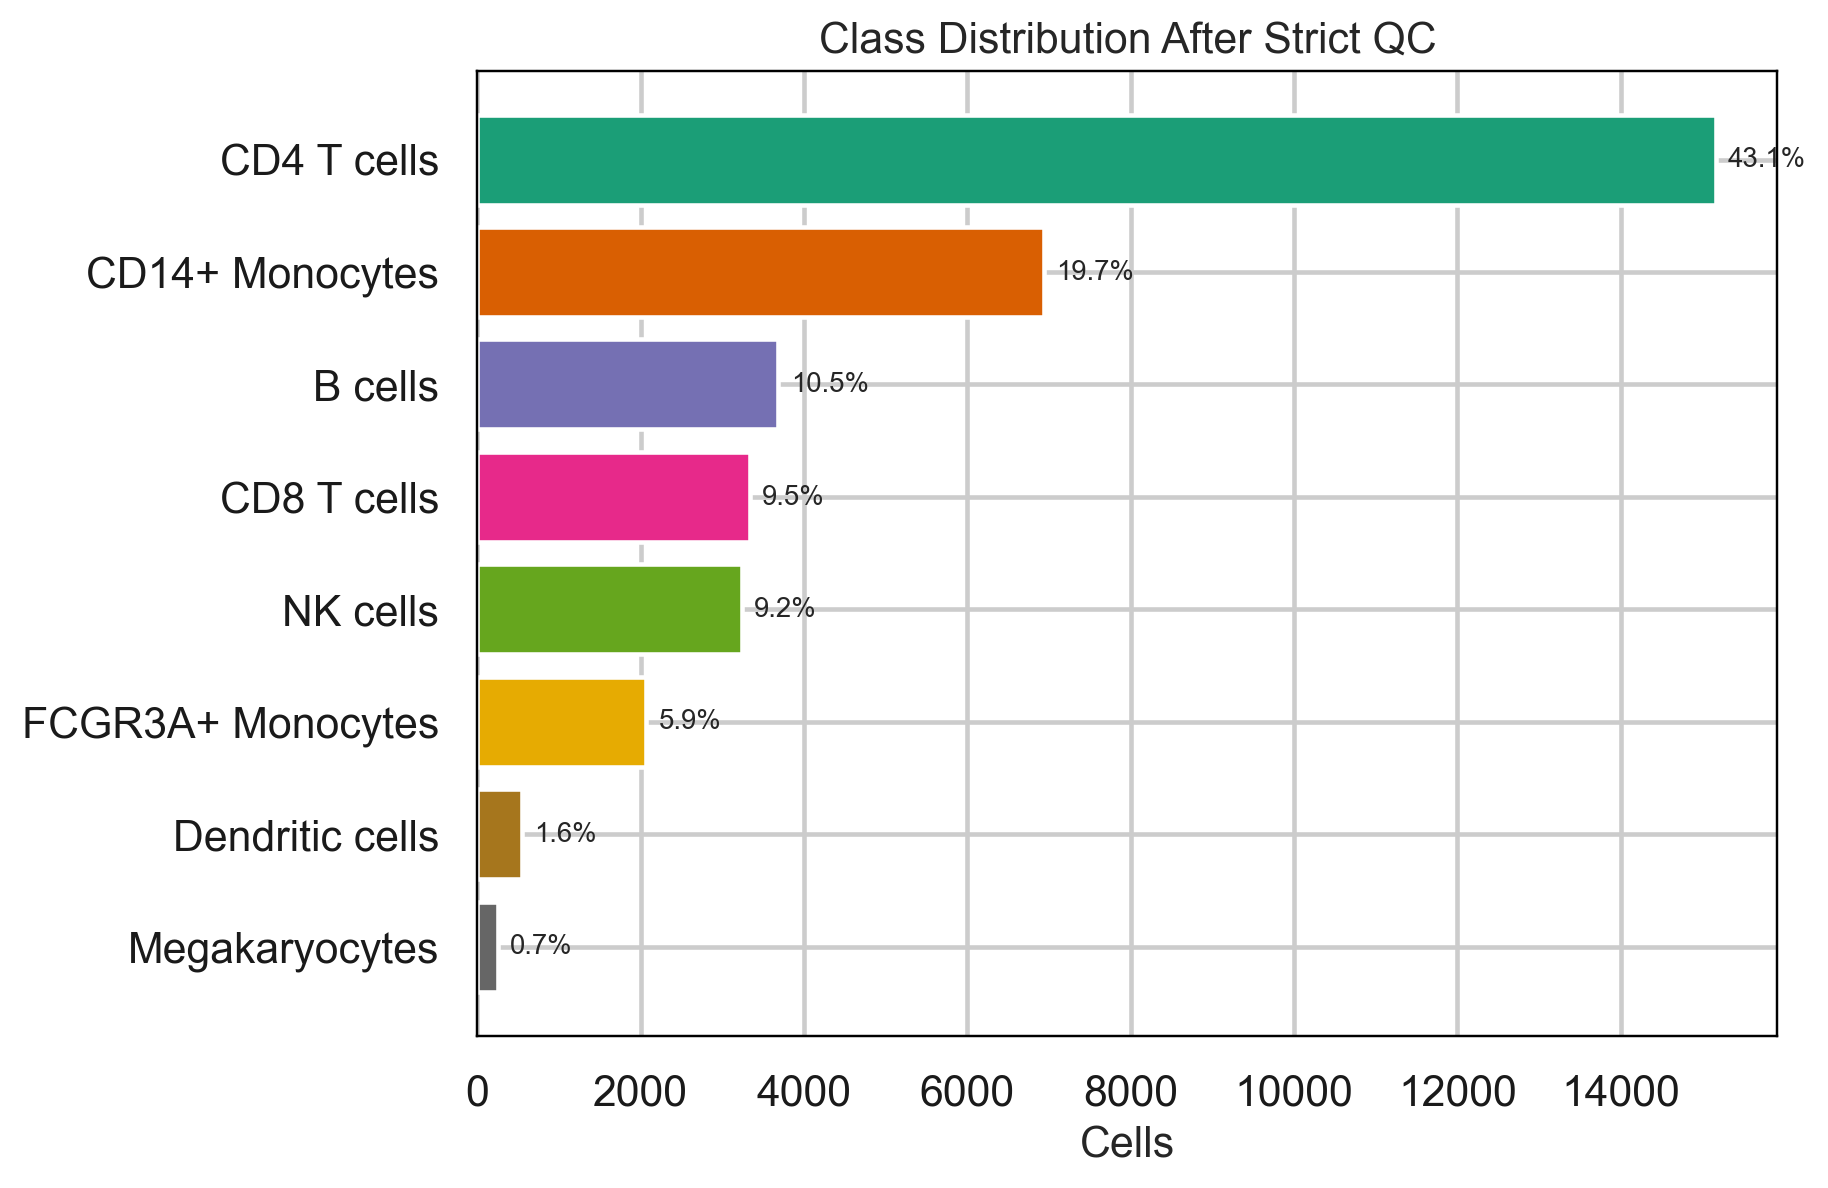

,cell_type,cells,percent,is_rare_under_2pct
6,Dendritic cells,547,1.553359,True
7,Megakaryocytes,246,0.698586,True


In [4]:
fig, ax = plt.subplots(figsize=(8.5, 5.6))
plot_df = cell_type_counts.sort_values('cells', ascending=True)
ax.barh(plot_df['cell_type'], plot_df['cells'], color=[CELL_PALETTE.get(x, '#777777') for x in plot_df['cell_type']])
ax.set_title('Class Distribution After Strict QC')
ax.set_xlabel('Cells')
ax.set_ylabel('')
for _, row in plot_df.iterrows():
    ax.text(row['cells'] + plot_df['cells'].max() * 0.01, row['cell_type'], f"{row['percent']:.1f}%", va='center', fontsize=9)
plt.tight_layout()
plt.show()

cell_type_counts.query('is_rare_under_2pct')


## Visualize: Batch / Condition Composition and QC


/var/folders/2b/_3yds0s92c343hz7_994phjm0000gn/T/ipykernel_18032/717849324.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cond_plot, x='condition', y='cells', palette=['#133C55', '#2E7D6F', '#C68B31'], ax=ax2)
/var/folders/2b/_3yds0s92c343hz7_994phjm0000gn/T/ipykernel_18032/717849324.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


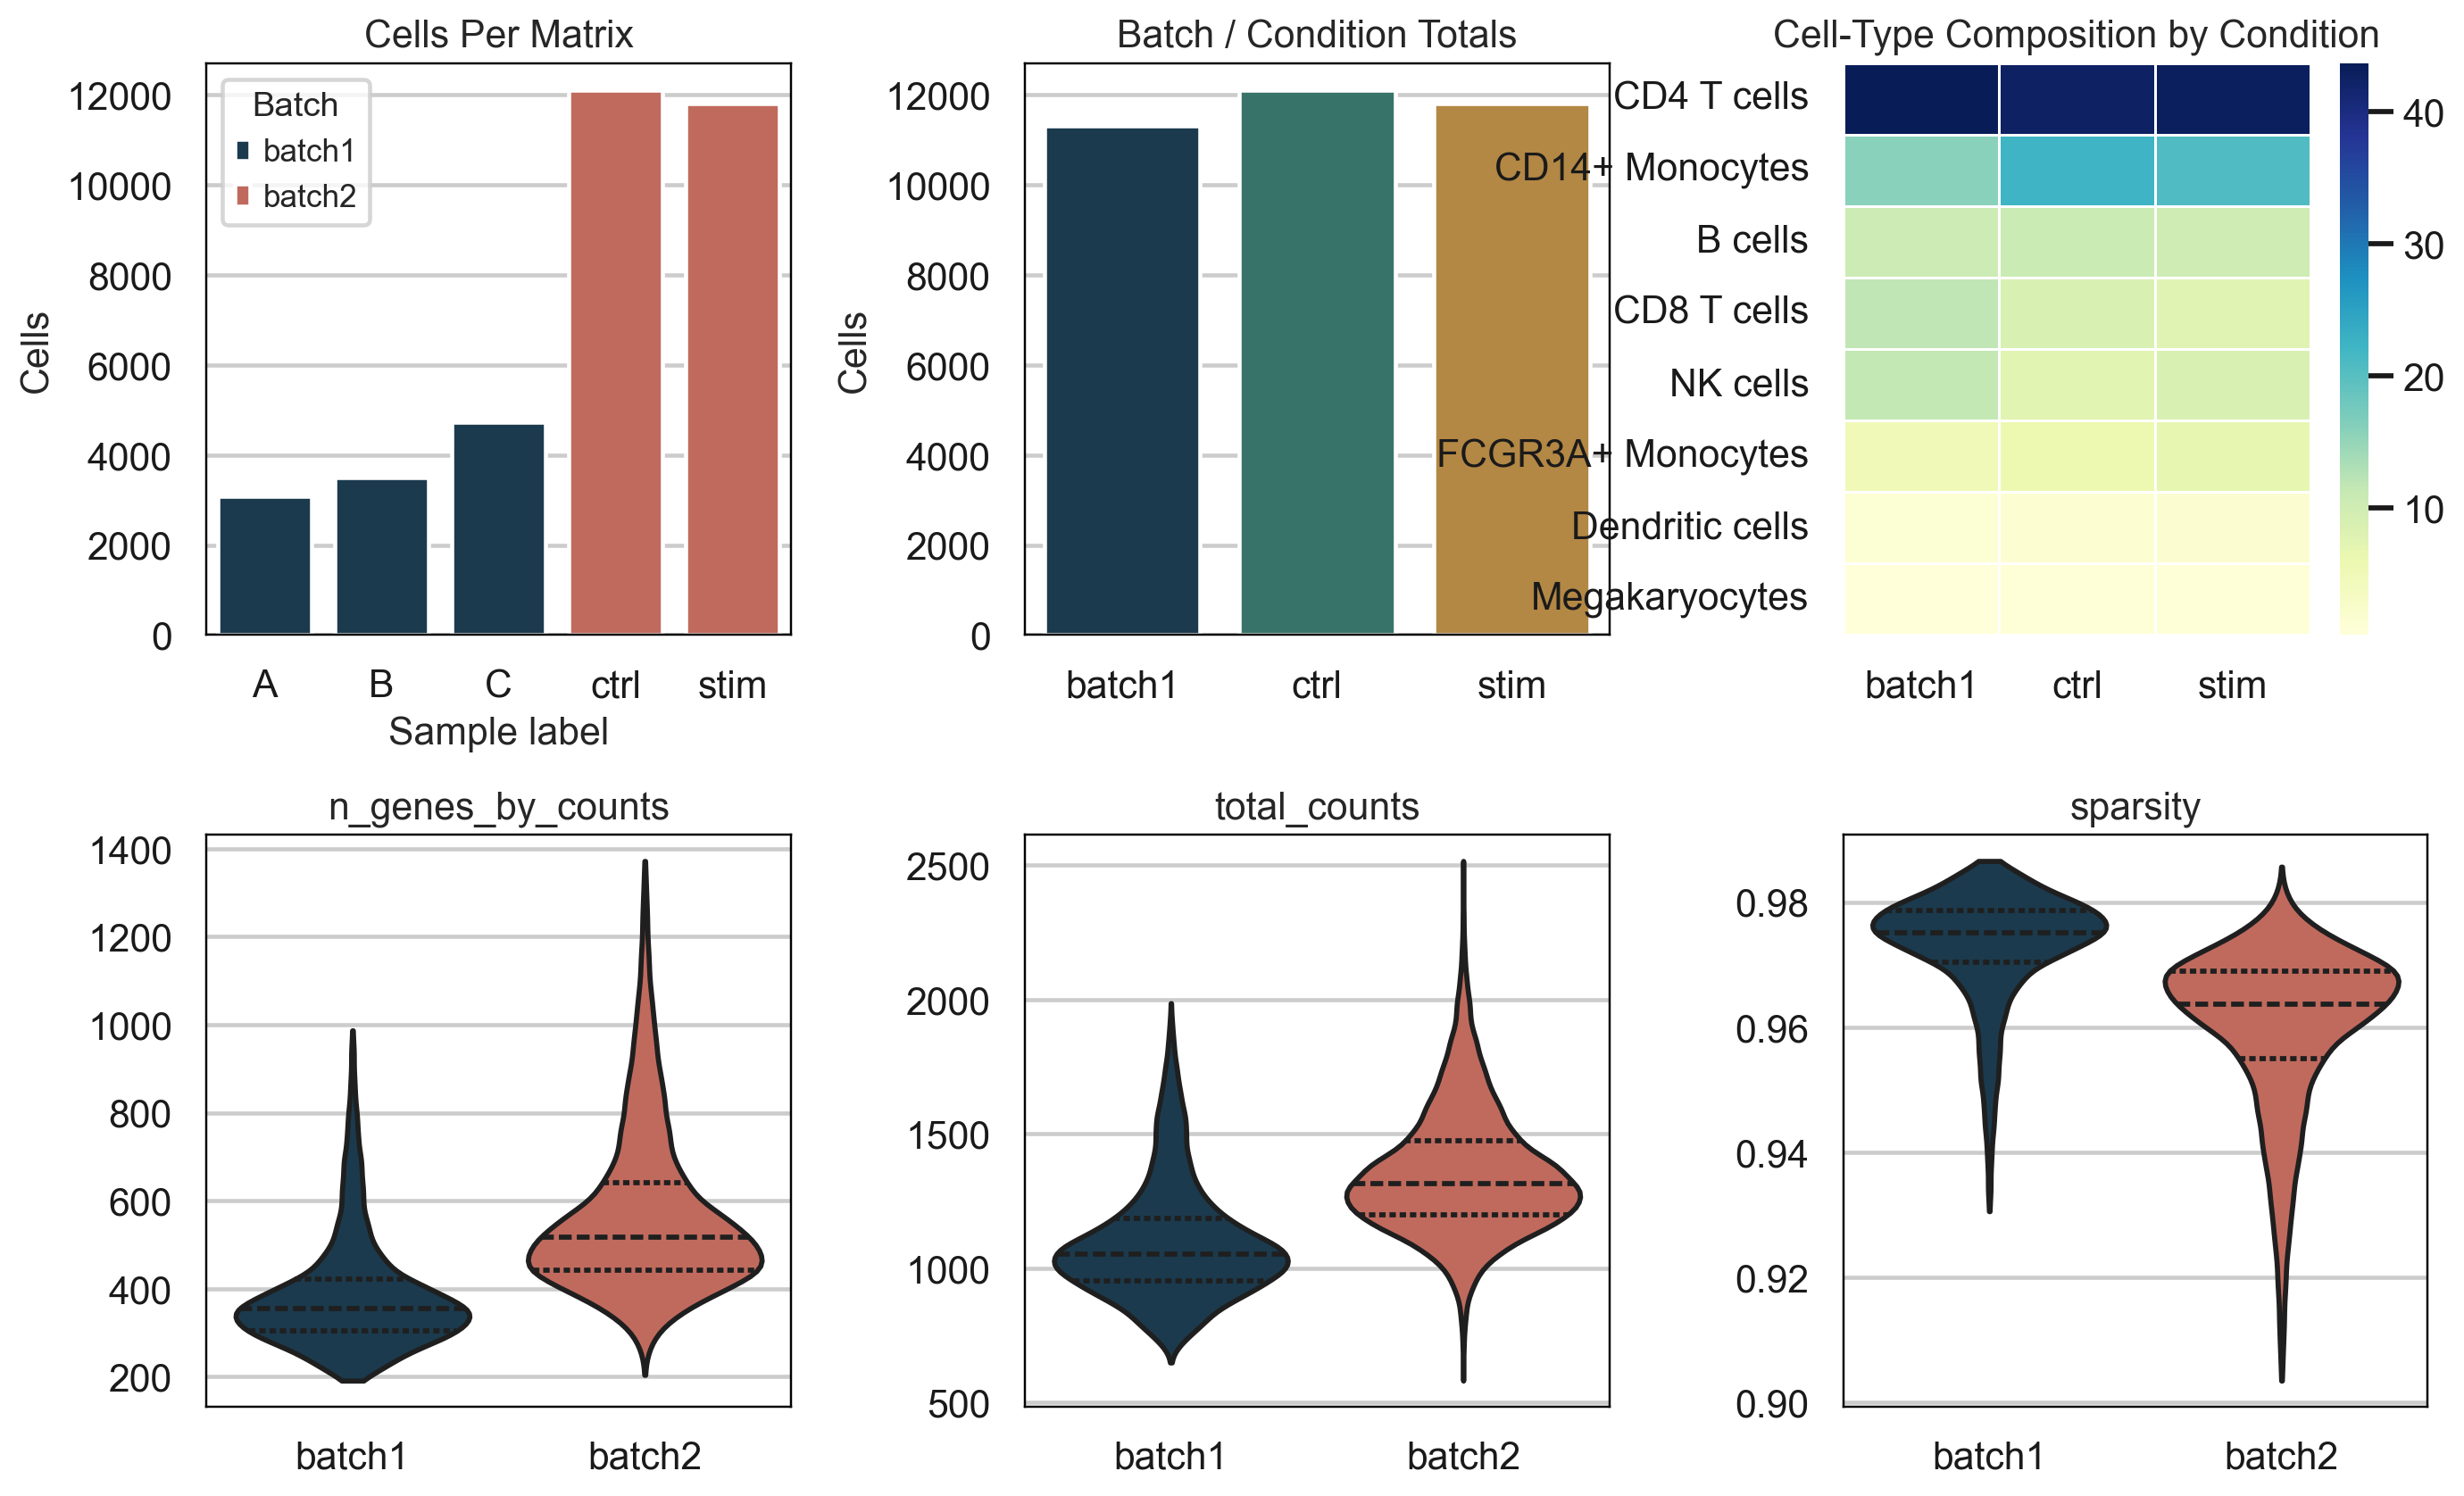

In [5]:
condition_counts = adata.obs['condition'].value_counts().rename_axis('condition').reset_index(name='cells')
composition = pd.crosstab(adata.obs['cell_type'], adata.obs['condition'], normalize='columns').mul(100)
qc_long = adata.obs[['batch_label', 'n_genes_by_counts', 'total_counts', 'sparsity']].copy()

fig = plt.figure(figsize=(14.5, 9.0))
gs = fig.add_gridspec(2, 3, height_ratios=[1.0, 1.0], wspace=0.4, hspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
sample_plot = sample_counts.copy()
sample_plot['sample_label'] = pd.Categorical(sample_plot['sample_label'], categories=['A', 'B', 'C', 'ctrl', 'stim'], ordered=True)
sample_plot = sample_plot.sort_values('sample_label')
sns.barplot(data=sample_plot, x='sample_label', y='cells', hue='batch_label', palette=BATCH_PALETTE, ax=ax1)
ax1.set_title('Cells Per Matrix')
ax1.set_xlabel('Sample label')
ax1.set_ylabel('Cells')
ax1.legend(title='Batch', fontsize=11.5, title_fontsize=12.5)

ax2 = fig.add_subplot(gs[0, 1])
cond_plot = condition_counts.assign(condition=pd.Categorical(condition_counts['condition'], categories=['batch1', 'ctrl', 'stim'], ordered=True)).sort_values('condition')
sns.barplot(data=cond_plot, x='condition', y='cells', palette=['#133C55', '#2E7D6F', '#C68B31'], ax=ax2)
ax2.set_title('Batch / Condition Totals')
ax2.set_xlabel('')
ax2.set_ylabel('Cells')

ax3 = fig.add_subplot(gs[0, 2])
sns.heatmap(composition.loc[cell_type_counts['cell_type'], ['batch1', 'ctrl', 'stim']], cmap='YlGnBu', linewidths=0.4, ax=ax3)
ax3.set_title('Cell-Type Composition by Condition')
ax3.set_xlabel('')
ax3.set_ylabel('')

for i, metric in enumerate(['n_genes_by_counts', 'total_counts', 'sparsity']):
    ax = fig.add_subplot(gs[1, i])
    sns.violinplot(data=qc_long, x='batch_label', y=metric, hue='batch_label', palette=BATCH_PALETTE, cut=0, inner='quartile', legend=False, ax=ax)
    ax.set_title(metric)
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()


## Analyze: Batch Effect Before Correction

Before correction, the embedding is strongly dominated by `batch1` vs `batch2`. The metrics below are computed on the first 20 PCA dimensions before and after Harmony.


In [6]:
metrics_summary = metrics_df.pivot(index='metric', columns='embedding', values='value').round(4)
metrics_summary


embedding,after_harmony,before_harmony
metric,,
neighbor_same_batch,0.7763,0.9950
neighbor_same_cell_type,0.9089,0.9095
neighbor_same_condition,0.7562,0.9728
silhouette_batch,-0.0163,0.0976
silhouette_cell_type,0.2106,0.1554
silhouette_condition,-0.0026,0.1134


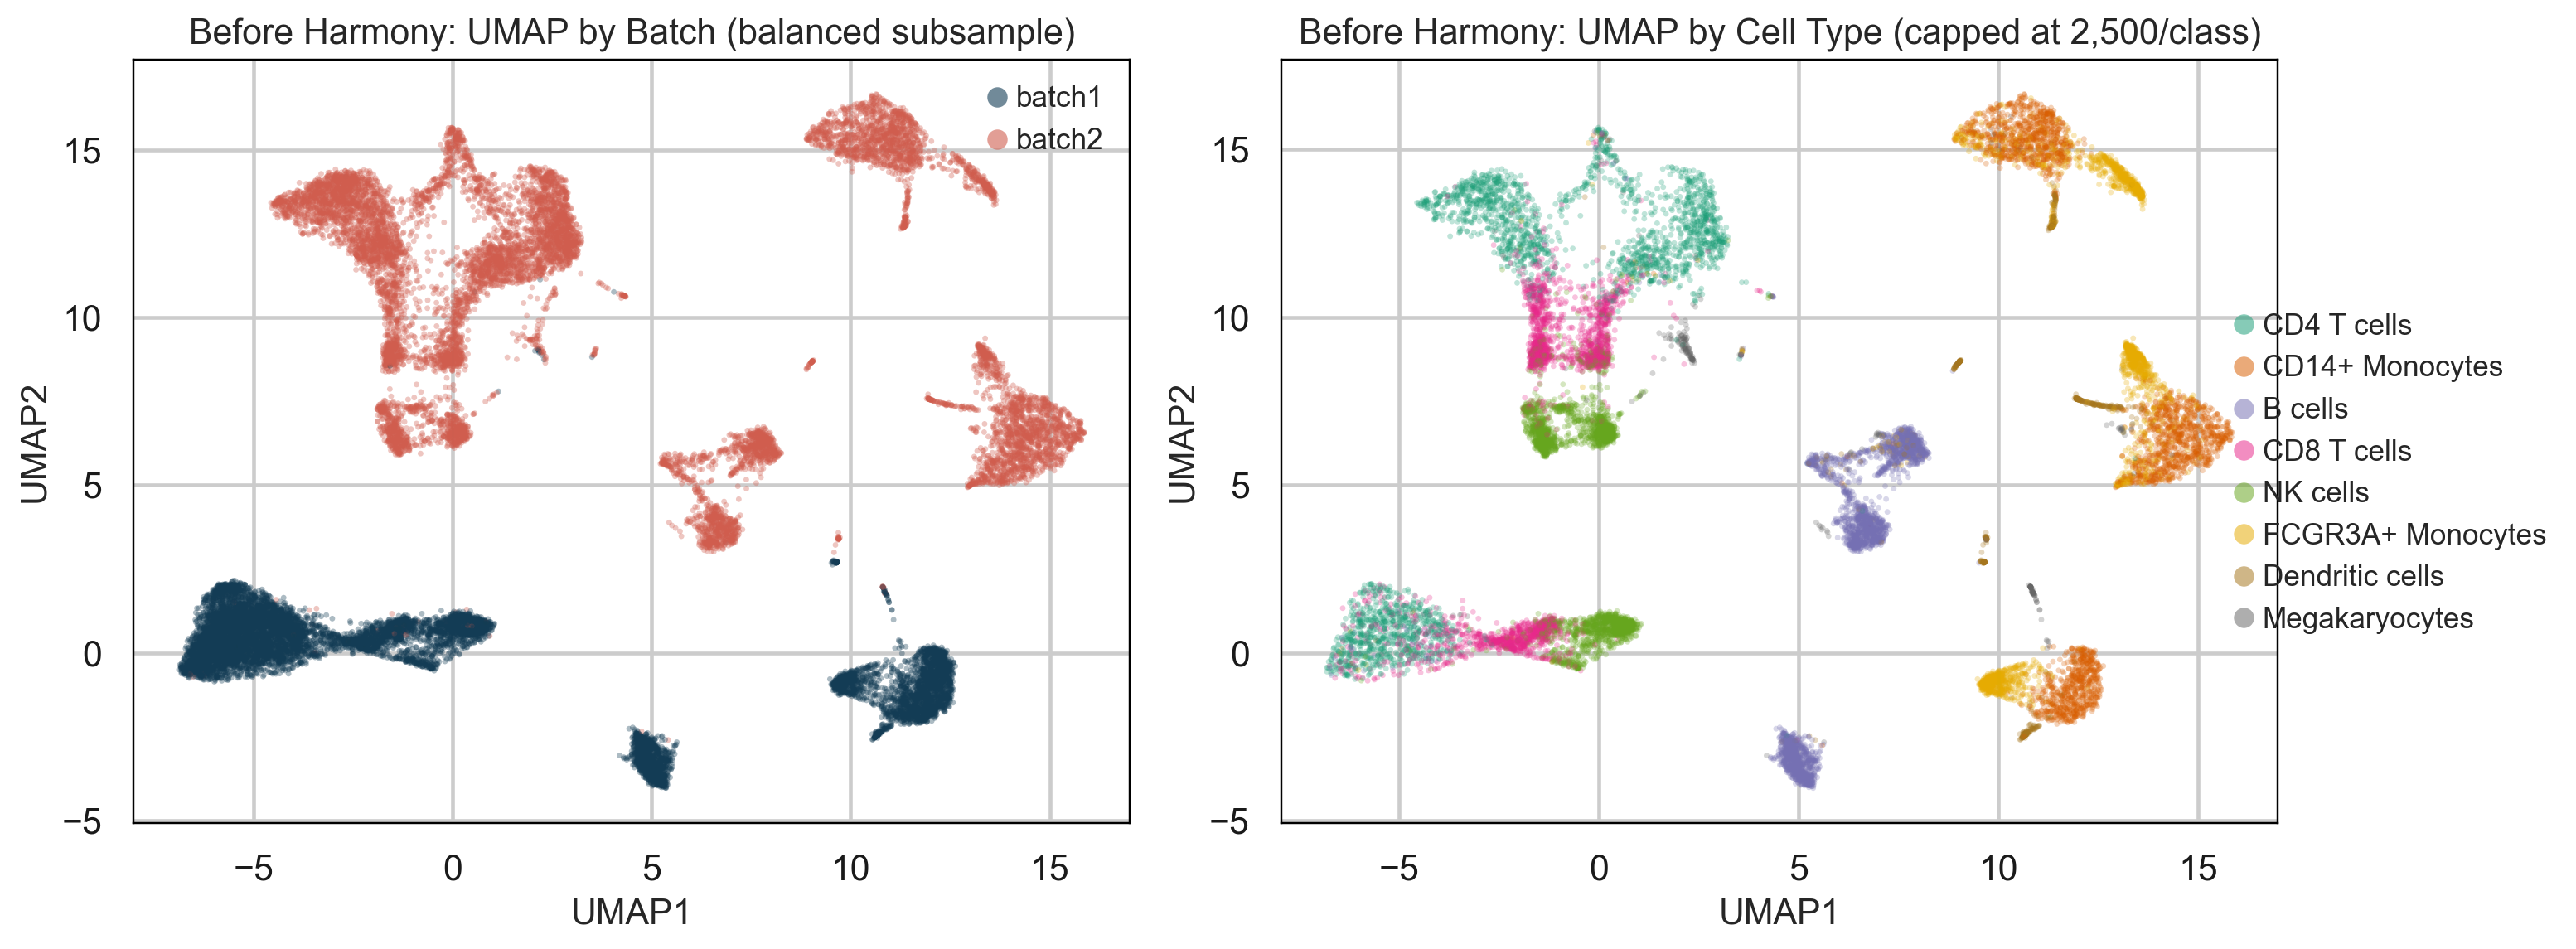

In [7]:
batch_idx = balanced_indices(adata.obs['batch_label'], random_state=0)
cell_idx = capped_indices(adata.obs['cell_type'], max_per_label=2500, random_state=1)
cell_type_order = list(adata.obs['cell_type'].value_counts().index)

fig, axes = plt.subplots(1, 2, figsize=(12.8, 5.4))
draw_embedding(
    axes[0],
    adata.obsm['X_umap'][batch_idx],
    adata.obs['batch_label'].iloc[batch_idx],
    BATCH_PALETTE,
    'Before Harmony: UMAP by Batch (balanced subsample)',
    ['batch1', 'batch2'],
    alpha=0.35,
    shuffle=True,
    random_state=0,
)
draw_embedding(
    axes[1],
    adata.obsm['X_umap'][cell_idx],
    adata.obs['cell_type'].iloc[cell_idx],
    CELL_PALETTE,
    'Before Harmony: UMAP by Cell Type (capped at 2,500/class)',
    cell_type_order,
    alpha=0.28,
)
axes[0].legend(handles=legend_handles(['batch1', 'batch2'], BATCH_PALETTE, adata.obs['batch_label'].iloc[batch_idx], alpha=0.35), frameon=False, fontsize=11.5, loc='best')
cell_handles = legend_handles(cell_type_order, CELL_PALETTE, adata.obs['cell_type'].iloc[cell_idx], alpha=0.28)
fig.legend(cell_handles, [h.get_label() for h in cell_handles], frameon=False, fontsize=11.5, bbox_to_anchor=(1.11, 0.5), loc='center right')
plt.tight_layout()
plt.show()


## Batch Correction: Harmony

Harmony is commonly used in the R / Seurat ecosystem, but here we run the Python wrapper `harmonypy` directly inside the notebook. The important point is the order of operations:

- per-batch normalization
- per-batch HVG selection
- union HVG space
- PCA
- Harmony on the PCA representation
- neighbors + UMAP on Harmony-corrected PCs


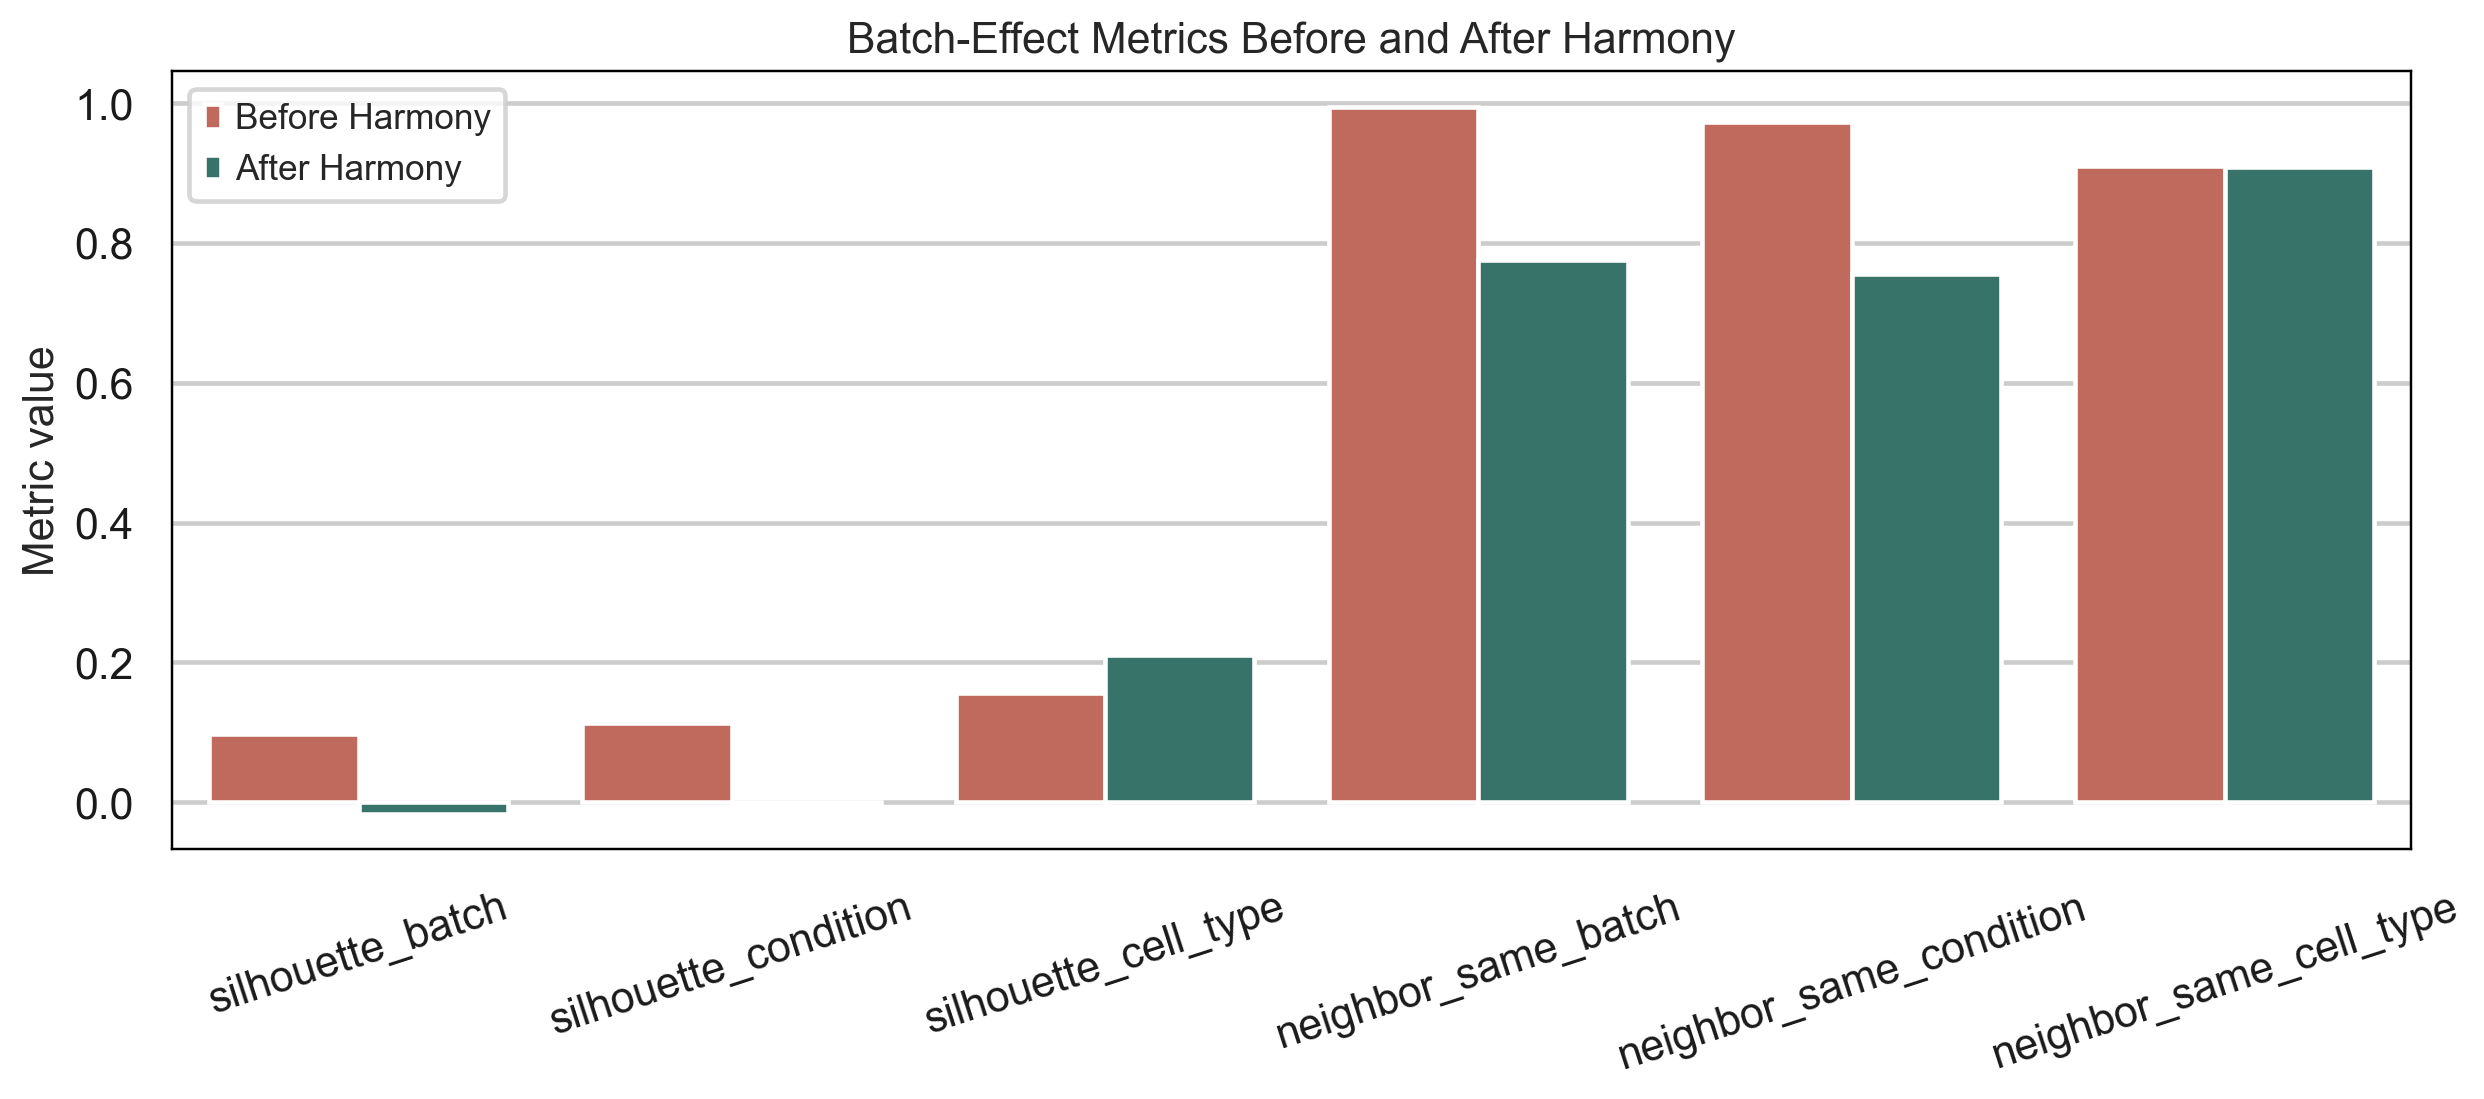

In [8]:
metric_plot = metrics_df.copy()
metric_plot['embedding'] = metric_plot['embedding'].map({'before_harmony': 'Before Harmony', 'after_harmony': 'After Harmony'})
metric_order = [
    'silhouette_batch', 'silhouette_condition', 'silhouette_cell_type',
    'neighbor_same_batch', 'neighbor_same_condition', 'neighbor_same_cell_type'
]

fig, ax = plt.subplots(figsize=(11.6, 5.2))
sns.barplot(data=metric_plot, x='metric', y='value', hue='embedding', order=metric_order, palette={'Before Harmony': '#D05D4E', 'After Harmony': '#2E7D6F'}, ax=ax)
ax.set_title('Batch-Effect Metrics Before and After Harmony')
ax.set_xlabel('')
ax.set_ylabel('Metric value')
ax.tick_params(axis='x', rotation=18)
ax.legend(title='', fontsize=11.5)
plt.tight_layout()
plt.show()


## Visualize: After Harmony

The batch-colored UMAP again uses a balanced subsample so batch size does not bias the visual. The cell-type panel caps very large classes so nearby smaller classes remain visible.


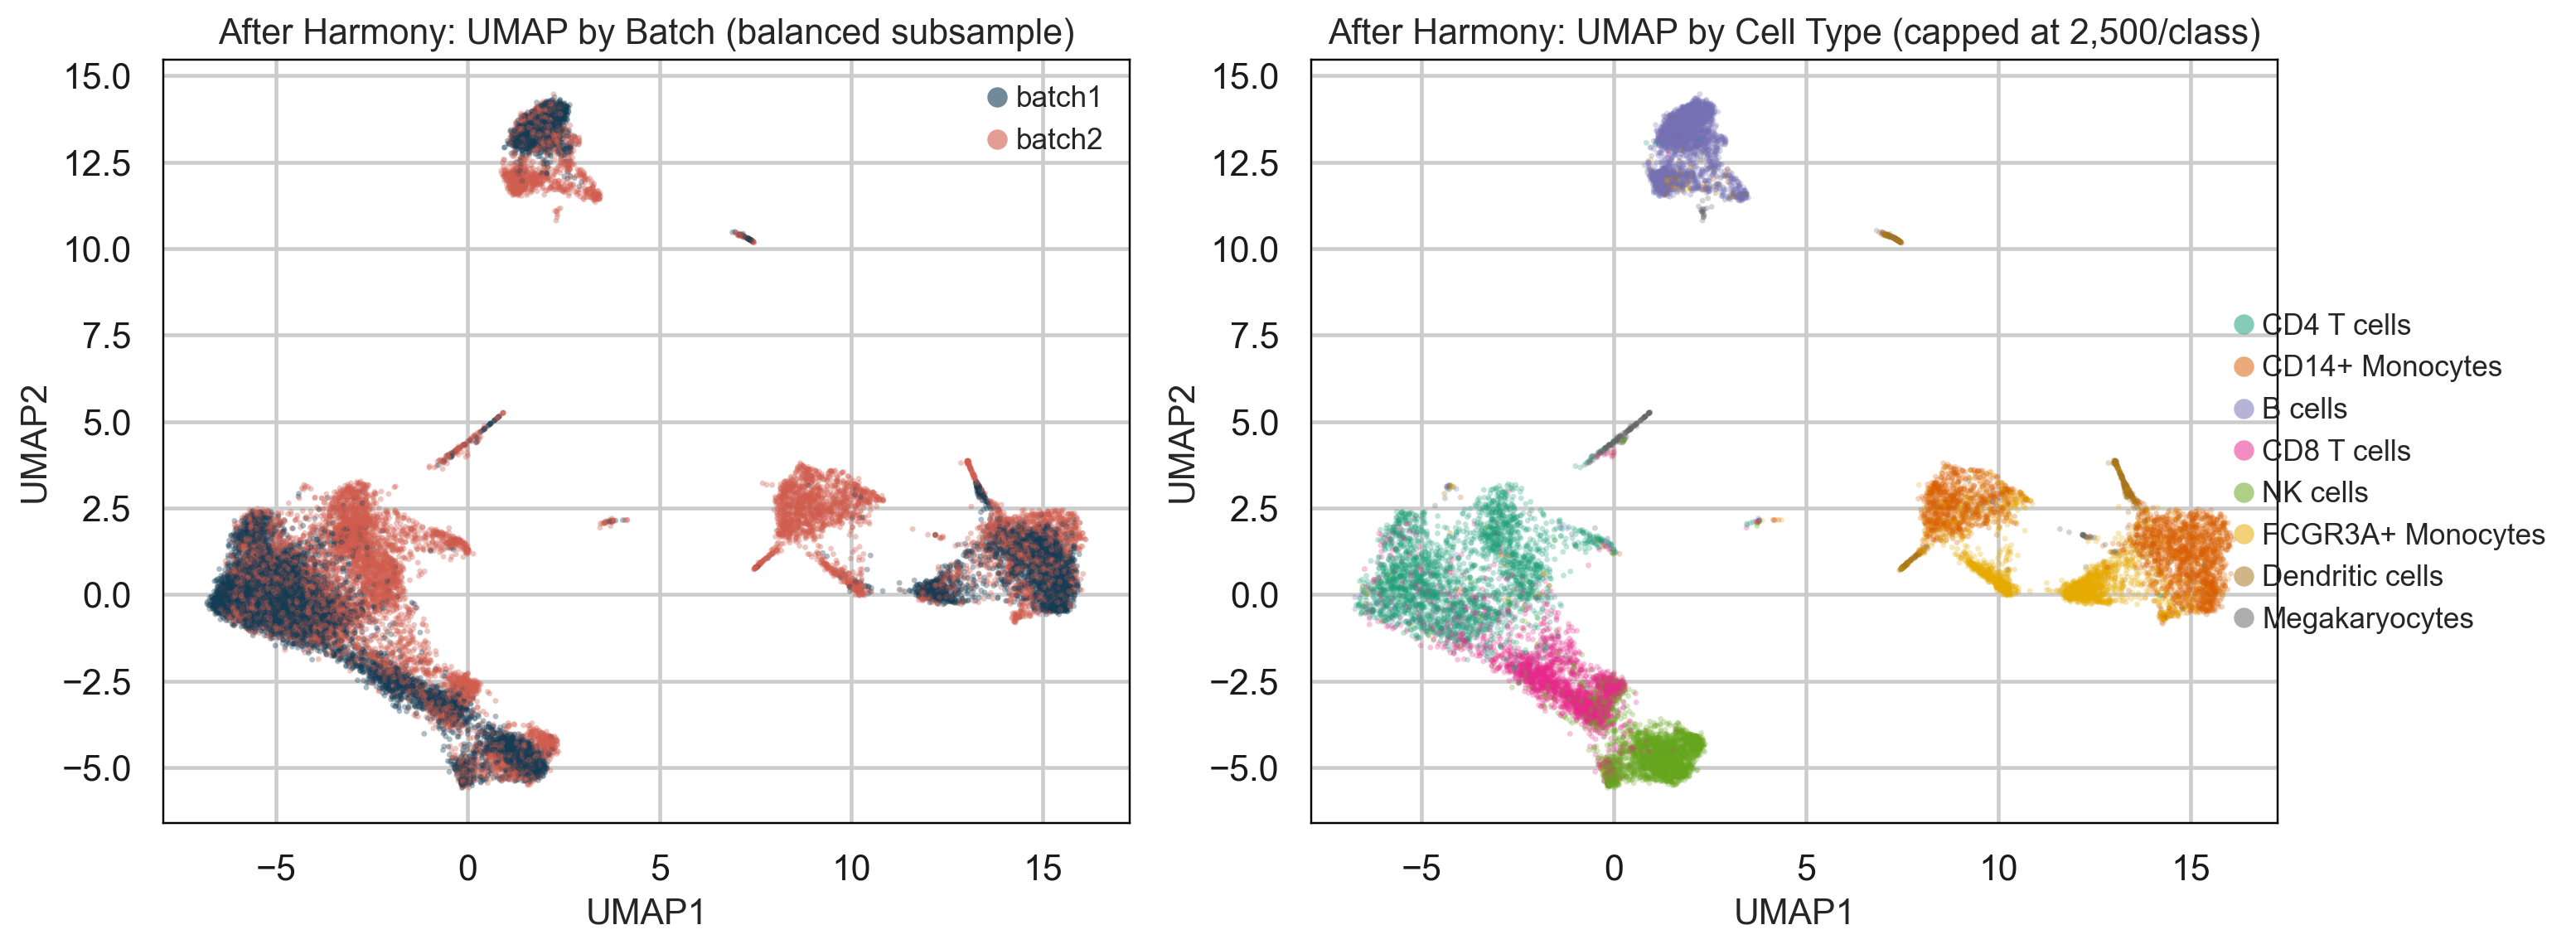

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12.8, 5.4))
draw_embedding(
    axes[0],
    adata.obsm['X_umap_harmony'][batch_idx],
    adata.obs['batch_label'].iloc[batch_idx],
    BATCH_PALETTE,
    'After Harmony: UMAP by Batch (balanced subsample)',
    ['batch1', 'batch2'],
    alpha=0.35,
    shuffle=True,
    random_state=2,
)
draw_embedding(
    axes[1],
    adata.obsm['X_umap_harmony'][cell_idx],
    adata.obs['cell_type'].iloc[cell_idx],
    CELL_PALETTE,
    'After Harmony: UMAP by Cell Type (capped at 2,500/class)',
    cell_type_order,
    alpha=0.28,
)
axes[0].legend(handles=legend_handles(['batch1', 'batch2'], BATCH_PALETTE, adata.obs['batch_label'].iloc[batch_idx], alpha=0.35), frameon=False, fontsize=11.5, loc='best')
cell_handles = legend_handles(cell_type_order, CELL_PALETTE, adata.obs['cell_type'].iloc[cell_idx], alpha=0.28)
fig.legend(cell_handles, [h.get_label() for h in cell_handles], frameon=False, fontsize=11.5, bbox_to_anchor=(1.11, 0.5), loc='center right')
plt.tight_layout()
plt.show()


## Insights

- `batch1` and `batch2` require explicit metadata alignment because the GEO release is fragmented across matrices, barcodes, gene tables, and metadata tables.
- After strict QC and singlet filtering, cross-batch analysis uses only the shared post-QC gene space.
- A full single-cell preprocessing flow matters here: per-batch normalization and per-batch HVG selection produce a cleaner Harmony result than a single pooled HVG pass.
- Harmony reduces batch structure while preserving cell-type structure well enough for milestone 2 EDA.
